PREPROCESSING

In [3]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys

!git clone https://github.com/QIFEIDKN/STAGATE_pyG && cd STAGATE_pyG && python setup.py build && python setup.py install

In [4]:
import torch
print(torch.__version__)

2.6.0+cu124


In [5]:
import torch
import STAGATE_pyG

c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import tqdm as notebook_tqdm

In [7]:
input_dir = 'data'
counts_file = os.path.join(input_dir, 'Puck_200127_15.digital_expression.txt')
coor_file = os.path.join(input_dir, 'Puck_200127_15_bead_locations.csv')

In [8]:
counts = pd.read_csv(counts_file, sep='\t', index_col=0)
coor_df = pd.read_csv(coor_file, index_col=0)
print(counts.shape, coor_df.shape)

(21220, 21724) (21724, 3)


In [9]:
print(coor_df.columns.tolist())
print(coor_df.head())

['xcoord', 'ycoord', 'barcode']
     xcoord  ycoord         barcode
0    10.298  3031.2  TTTTTTTTTTTTTT
1  3352.500  2498.0  GCTAGGATTGTAAA
2  3687.400  4701.0  CACAACAACGTTGG
3  2706.900  2504.5  AATGACGGCAATGC
4  2786.800  3984.3  TATTTTAGATCTCA


In [10]:
coor_df = pd.read_csv(coor_file, index_col=0)
coor_df.index = coor_df['barcode']

In [11]:
adata = sc.AnnData(counts.T)
adata.var_names_make_unique()
coor_df = coor_df.loc[adata.obs_names, ['xcoord', 'ycoord']]
adata.obsm["spatial"] = coor_df.to_numpy()

In [12]:
print(coor_df.index[:5])
print(adata.obs_names[:5])

Index(['TTTTTTTTTTTTTT', 'GCTAGGATTGTAAA', 'CACAACAACGTTGG', 'AATGACGGCAATGC',
       'TATTTTAGATCTCA'],
      dtype='object')
Index(['TTTTTTTTTTTTTT', 'GCTAGGATTGTAAA', 'CACAACAACGTTGG', 'AATGACGGCAATGC',
       'TATTTTAGATCTCA'],
      dtype='object')


In [13]:
sc.pp.calculate_qc_metrics(adata, inplace=True) #Compute quality control statistics (like total counts and number of genes per spot)
                                                #and store them inside the AnnData object for later filtering and analysis.

In [14]:
adata

AnnData object with n_obs × n_vars = 21724 × 21220
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

(np.float64(-289.81710000000004),
 np.float64(6312.7151),
 np.float64(173.30850000000004),
 np.float64(5709.8615))

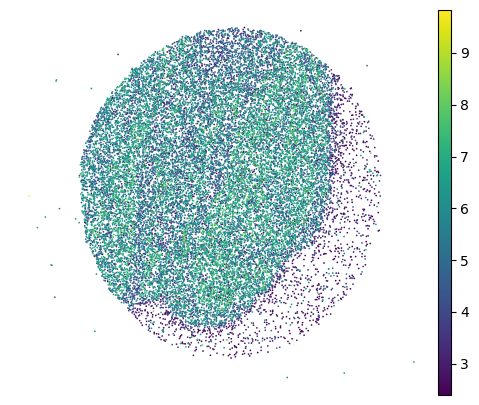

In [15]:
plt.rcParams["figure.figsize"] = (6,5)
sc.pl.embedding(adata, basis="spatial", color="log1p_total_counts",s=6, show=False)
plt.title('')
plt.axis('off')

now we are removing the spots outside the main tissue area (filter the spots)

In [16]:
used_barcode = pd.read_csv('data/used_barcodes.txt', sep='\t', header=None)
used_barcode = used_barcode[0]

In [17]:
adata = adata[used_barcode,]

(np.float64(588.545),
 np.float64(5108.555),
 np.float64(847.6700000000001),
 np.float64(5670.73))

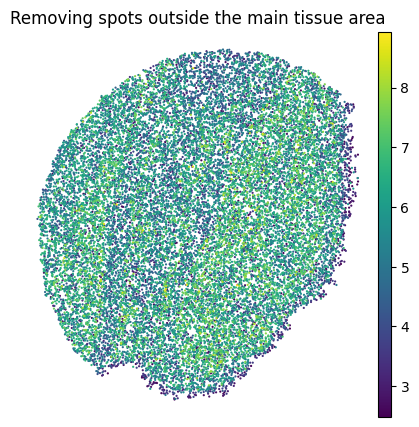

In [18]:
plt.rcParams["figure.figsize"] = (5,5)
sc.pl.embedding(adata, basis="spatial", color="log1p_total_counts",s=10, show=False, title='Removing spots outside the main tissue area')

plt.axis('off')

filter the genes

In [21]:
sc.pp.filter_genes(adata, min_cells=50)
print('After flitering: ', adata.shape)

After flitering:  (20139, 11750)


now doing normalization

!{sys.executable} -m pip install scikit-misc

In [23]:
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

CONSTRUCTING THE SPATIAL NETWORK

------Calculating spatial graph...
The graph contains 228300 edges, 20139 cells.
11.3362 neighbors per cell on average.


c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\STAGATE_pyG\utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\STAGATE_pyG\utils.py:194: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['Spatial_Net']['Cell1']))


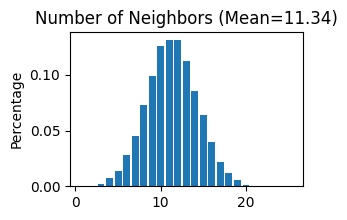

In [24]:
STAGATE_pyG.Cal_Spatial_Net(adata, rad_cutoff=50)
STAGATE_pyG.Stats_Spatial_Net(adata)

uninstalling current cpu version of torch and installing cuda version

In [25]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # Should print True

2.6.0+cu124
True


RUNNING STAGATE

In [26]:
adata = STAGATE_pyG.train_STAGATE(adata, device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'))

Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [03:16<00:00,  5.08it/s]


now make neighbour graph and use umap to get 2d representation of the graph

In [27]:
sc.pp.neighbors(adata, use_rep='STAGATE')
sc.tl.umap(adata)

import sys
!{sys.executable} -m pip install igraph

!{sys.executable} -m pip install leidenalg

In [28]:
sc.tl.leiden(adata, resolution=0.5)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13428\2104492833.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


In [29]:
adata.obsm["spatial"] = adata.obsm["spatial"] * (-1)


(np.float64(-5108.555),
 np.float64(-588.545),
 np.float64(-5670.73),
 np.float64(-847.6700000000001))

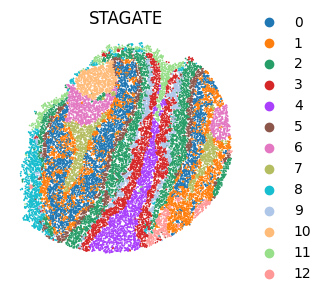

In [30]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.embedding(adata, basis="spatial", color="leiden",s=6, show=False, title='STAGATE')
plt.axis('off')

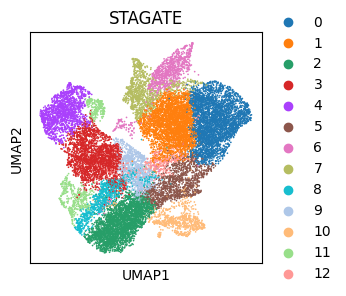

In [31]:
sc.pl.umap(adata, color='leiden', title='STAGATE')

NOW DO THE PERTURBATION ANALYSIS

In [32]:
import copy

adata_original = adata.copy()
adata_perturbed = adata.copy()

In [33]:
print(adata.var_names[adata.var['highly_variable']][:10].tolist())

['0610030E20Rik', '1110002L01Rik', '1110019D14Rik', '1190005I06Rik', '1200014J11Rik', '1500009C09Rik', '1500015O10Rik', '1500017E21Rik', '1600012H06Rik', '1700008J07Rik']


In [34]:
gene_that_is_perturbed = '1110002L01Rik'
adata_perturbed[:,gene_that_is_perturbed].X = 0

c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\anndata\_core\anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13428\1490439163.py:2: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_perturbed[:,gene_that_is_perturbed].X = 0
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


no need to reconstruct spatial network as it is based on physical coordinates of cells and not based on gene expressions.

In [35]:
adata_perturbed = STAGATE_pyG.train_STAGATE(adata_perturbed, device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'))

Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [03:04<00:00,  5.42it/s]


In [36]:
sc.pp.neighbors(adata_perturbed, use_rep='STAGATE')
sc.tl.umap(adata_perturbed)

In [37]:
sc.tl.leiden(adata_perturbed, resolution=0.5)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13428\3608109182.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_perturbed, resolution=0.5)


In [38]:
adata_perturbed.obsm["spatial"] = adata_perturbed.obsm["spatial"] * (-1)

(np.float64(588.545),
 np.float64(5108.555),
 np.float64(847.6700000000001),
 np.float64(5670.73))

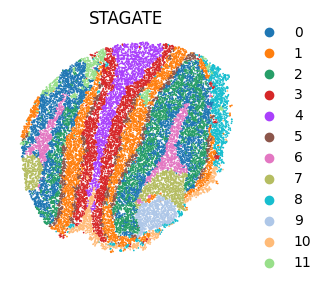

In [39]:
plt.rcParams["figure.figsize"] = (3, 3)
sc.pl.embedding(adata_perturbed, basis="spatial", color="leiden",s=6, show=False, title='STAGATE')
plt.axis('off')

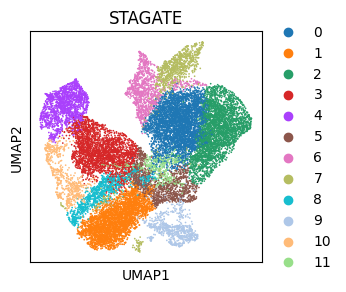

In [40]:
sc.pl.umap(adata_perturbed, color='leiden', title='STAGATE')

NOW FINDING THE ARI

In [41]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(adata.obs['leiden'], adata_perturbed.obs['leiden'])
print(ari)

0.791406272075477


In [42]:
ari_scores = []
genes = []
for gene in adata.var_names[adata.var['highly_variable']][:25]:
    adata_perturbed = adata.copy()
    adata_perturbed[:, gene].X = 0
    adata_perturbed = STAGATE_pyG.train_STAGATE(adata_perturbed, device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'))
    sc.pp.neighbors(adata_perturbed, use_rep='STAGATE')
    sc.tl.umap(adata_perturbed)
    ari_scores.append(adjusted_rand_score(adata.obs['leiden'], adata_perturbed.obs['leiden']))
    genes.append(gene)
print(ari_scores)
print(genes)

c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\anndata\_core\anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13428\3624752129.py:5: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_perturbed[:, gene].X = 0
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:05<00:00,  7.99it/s]
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\anndata\_core\anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13428\3624752129.py:5: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_perturbed[:, gene].X = 0
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:05<00:00,  7.98it/s]
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\anndata\_core\anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13428\3624752129.py:5: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_perturbed[:, gene].X = 0
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


...

Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:05<00:00,  7.98it/s]
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\anndata\_core\anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
C:\Users\ASUS\AppData\Local\Temp\ipykernel_13428\3624752129.py:5: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_perturbed[:, gene].X = 0
c:\Users\ASUS\Desktop\ALL_VS_CODE_FILLES\CauST_GSOC_26_prep\.best_venv\Lib\site-packages\scipy\sparse\_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:05<00:00,  7.99it/s]


[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
['0610030E20Rik', '1110002L01Rik', '1110019D14Rik', '1190005I06Rik', '1200014J11Rik', '1500009C09Rik', '1500015O10Rik', '1500017E21Rik', '1600012H06Rik', '1700008J07Rik', '1700010I14Rik', '1700011I03Rik', '1700012B09Rik', '1700016P03Rik', '1700025G04Rik', '1700037C18Rik', '1700037H04Rik', '1700047M11Rik', '1700048O20Rik', '1700109H08Rik', '1700112E06Rik', '1810032O08Rik', '2010111I01Rik', '2010315B03Rik', '2210018M11Rik']


In [46]:
ari_scores = []
genes = []
import scipy.sparse as sp
for gene in adata.var_names[adata.var['highly_variable']][:10]:
    adata_perturbed = adata.copy()
    gene_idx = adata_perturbed.var_names.get_loc(gene)
    X = adata_perturbed.X.toarray()  # convert to dense numpy array
    X[:, gene_idx] = 0               # zero out the gene
    adata_perturbed.X = sp.csr_matrix(X)  # convert back to csr
    adata_perturbed = STAGATE_pyG.train_STAGATE(adata_perturbed, device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'))
    sc.pp.neighbors(adata_perturbed, use_rep='STAGATE')
    sc.tl.leiden(adata_perturbed, resolution=0.5, flavor='igraph', n_iterations=2, directed=False)
    ari_scores.append(adjusted_rand_score(adata.obs['leiden'], adata_perturbed.obs['leiden']))
    genes.append(gene)

print(sorted(zip(genes, ari_scores), key=lambda x: x[1]))

Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:09<00:00,  7.73it/s]


Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:09<00:00,  7.74it/s]


Size of Input:  (20139, 3000)


...

Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:08<00:00,  7.79it/s]


Size of Input:  (20139, 3000)


100%|██████████| 1000/1000 [02:09<00:00,  7.73it/s]


[('1110002L01Rik', 0.5863498801491869), ('1600012H06Rik', 0.6271846172643678), ('1500017E21Rik', 0.6385531766901293), ('1110019D14Rik', 0.6704127404390677), ('1200014J11Rik', 0.6761321848875863), ('1700008J07Rik', 0.7006329774030677), ('1500015O10Rik', 0.7060211110190154), ('0610030E20Rik', 0.7446558497381855), ('1190005I06Rik', 0.7670501014742178), ('1500009C09Rik', 0.8279034454909847)]
